In [1]:
from models import U_Net, AttU_Net
from train import train_2D, test_2D
from utils import compare_predictions_ground_truth, prepare_data, graph
from torch.utils.data import TensorDataset, DataLoader

In [3]:
(X_train_tensor,
X_validation_tensor,
X_test_tensor,
y_train_tensor,
y_validation_tensor,
y_test_tensor) = prepare_data(train_size = 14, validation_size=2, rand = True, data_path="data")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=4, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

[14, 8, 3, 11, 10, 16, 1, 12, 5, 18, 2, 0, 4, 9, 15, 7, 13, 19, 6, 17]
X_train.shape :  (467, 1, 256, 256)
X_validation.shape :  (61, 1, 256, 256)
X_test.shape :  (119, 1, 256, 256)


In [4]:
train_loss,validation_losses = train_2D(
    model=AttU_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="attU_Net_10epochs",
    num_epochs=10,
    lr=1e-4,
    max_no_upgrade=100
)

Epoch 1 validation loss: 0.6233
Epoch 1 training loss: 0.7768
Previous best loss on validation set : inf | Loss on validation set at this epoch : 0.6233
Epoch 2 validation loss: 0.5373
Epoch 2 training loss: 0.6019
Previous best loss on validation set : 0.6233 | Loss on validation set at this epoch : 0.5373


KeyboardInterrupt: 

In [5]:
test_loss,dice_classes = test_2D(
    model=AttU_Net(1, 5),
    test_loader=test_loader,
    name ="attU_Net_weightstest"
)

Loss on test dataset: 0.1732
Dice per class on test dataset: [0.98811379 0.84296579 0.58385539 0.57869809 0.48646599]


In [7]:
graph(train_loss,validation_losses)

NameError: name 'train_loss' is not defined

[  0.  80. 160. 240. 255.]
torch.Size([1, 1, 256, 256])
torch.Size([256, 256])
torch.Size([256, 256])
(256, 256)
torch.Size([256, 256])


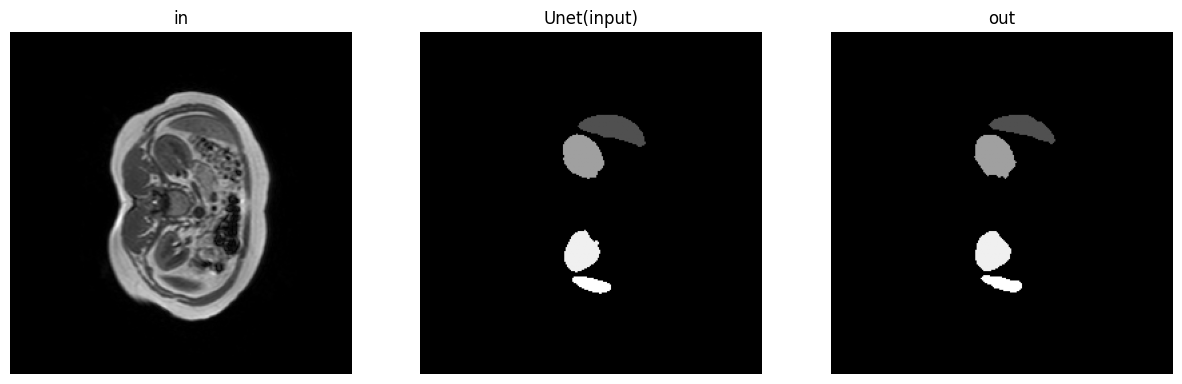

In [8]:
compare_predictions_ground_truth(U_Net(1,5), "model_weights10.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")